# Scaling law plots

Read the results of a scaling law fit and plot a few things:

1. The residuals of the fit to the complete dataset. To check for strucutre in the residuals
2. Plots showing the bootstrap-generated pairwise correlations between the fit parameters
3. The capacity retained plot (main text Fig. 1)
4. The scaling law parameters with error bars (main text Fig. 3)



In [2]:
import os, sys, json

# Repo root on the path (for `nano_llama` and `scaling_law`), from either cwd.
_HERE = os.getcwd()
for _cand in (_HERE, os.path.dirname(_HERE)):
    if os.path.isdir(os.path.join(_cand, "nano_llama")) and _cand not in sys.path:
        sys.path.insert(0, _cand)
os.environ.setdefault("JAX_PLATFORMS", "cpu")

import numpy as np
import matplotlib.pyplot as plt
plt.style.use("default")

import scaling_law as est
from scaling_law import fit_store

# scaling law fit data
ARTIFACT_DIR = "/media/trevor/data_flash/scaling_law_fits/2026-08-26-18-38-03"#/media/trevor/data_flash/scaling_law_fits/2026-08-26-11-45-13"

analyses, manifest = fit_store.load_analyses(ARTIFACT_DIR)
ps = sorted(analyses)
colors = plt.cm.viridis(np.linspace(0.08, 0.94, len(ps)))
CMAP, NORM = "viridis", plt.Normalize(min(ps), max(ps))
N_LABEL = "N  (total params)"     # the fitter has no N-column switch: N is always total params
PARAMS = est.PARAM_NAMES

_PTITLE = {"E": "$E$", "a": "$a$", "alpha1": r"$\alpha_1$",
           "alpha2": r"$\alpha_2$", "b": "$b$", "beta1": r"$\beta_1$",
           "beta2": r"$\beta_2$"}

def sm(ax):
    """Attach the shared p_train colourbar to `ax` (list or single)."""
    s = plt.cm.ScalarMappable(cmap=CMAP, norm=NORM)
    return plt.gcf().colorbar(s, ax=ax, label="p_train", fraction=0.02, pad=0.02)

_piv = manifest.get("pivots", {})
print(f"{len(ps)} cohorts, {sum(np.size(analyses[p]['arr']['L']) for p in ps)} runs   |   N = {N_LABEL}"
      + (f"   |   pivots N0 = {_piv['N0']:.4g}, D0 = {_piv['D0']:.4g}" if _piv else ""))

17 cohorts, 1810 runs   |   N = N  (total params)   |   pivots N0 = 4e+07, D0 = 4e+07


## 1. Fit summary

In [5]:
m = manifest
print(f"created      : {m['created']}")
print(f"source       : {m['processed_dir']}")
print(f"condition    : {m['condition']}, k_train = {m['k_train']:g}")
print(f"N            : {N_LABEL}")
print(f"fix_E        : {m['fix_E']}" + ("   <- E FITTED, not pinned" if m["fix_E"] is None else ""))
b = m["bootstrap"]
print(f"screen       : {m['filters']}")

# What the screen removed, pooled over cohorts -- a screen nobody reports back is a screen that lies.
fr = m["filter_report"]
by = {}
for v in fr.values():
    for r, n in v["by_reason"].items():
        by[r] = by.get(r, 0) + n
n_before = sum(v["n_before"] for v in fr.values())
n_after = sum(v["n_after"] for v in fr.values())
print(f"\nscreen dropped {n_before - n_after} of {n_before} runs -> {n_after} kept"
      + (f"   ({', '.join(f'{n} by {r}' for r, n in sorted(by.items()))})" if by else ""))
k0 = sorted(fr)[0]
print(f"  per cohort, ne_frac min {fr[k0]['ne_frac_min_before']:.3f} -> {fr[k0]['ne_frac_min_after']:.3f}"
      f" | L max {fr[k0]['L_max_before']:.3f} -> {fr[k0]['L_max_after']:.3f}")
if set(by) == {"min_ne_frac"} and m["filters"].get("max_ceiling_frac"):
    print("  NOTE: every drop is min_ne_frac -- on this array the shape screen SUBSUMES the loss "
          "ceiling,\n        so max_ceiling_frac had nothing left to remove.")

# Per-cohort table: the fit, its convergence witness, and (with E free) the E boundary mass.
print(f"\n{'p_train':>8}{'n':>6}{'E':>9}{'a':>9}{'alpha1':>9}{'alpha2':>9}{'beta1':>9}"
      f"{'rmse_log':>10}{'boot E med':>12}{'E 95% CI':>22}{'E at 0':>9}{'starts':>10}")
print("-" * 126)
BOUND = 1e-6                     # "E is at the boundary" -- below this the floor term is inert
bmass = {}
for i, p in enumerate(ps):
    a = analyses[p]
    E = a["boot"].samples["E"]
    bmass[p] = float(np.mean(E < BOUND))
    lo, hi = np.percentile(E, [2.5, 97.5])
    st = m["cohorts"][i].get("starts", {})
    sw = f"{st.get('point_at_optimum', '?')}/{st.get('point_starts', '?')}"
    f_ = a["fit"]
    print(f"{p:>8g}{np.size(a['arr']['L']):>6}{f_.E:>9.4f}{f_.a:>+9.4f}{f_.alpha1:>+9.4f}"
          f"{f_.alpha2:>+9.4f}{f_.beta1:>+9.4f}{a['diag']['rmse_log']:>10.4f}{np.median(E):>12.4f}"
          f"{f'[{lo:.3f}, {hi:.3f}]':>22}{bmass[p]:>9.0%}{sw:>10}")
_st = [m["cohorts"][i].get("starts", {}) for i in range(len(ps))]
_resc = [s.get("n_rescued", 0) for s in _st]

created      : 2026-08-26 18:39:16
source       : /mnt/storage/eval_summaries/training_2026-08-26-11-43-09
condition    : matched, k_train = 4
N            : N  (total params)
fix_E        : 1.85
screen       : {'max_ceiling_frac': 1.0, 'min_tpp': 5, 'min_ne_frac': 0.5}

screen dropped 1421 of 3231 runs -> 1810 kept   (1081 by min_ne_frac, 340 by min_tpp)
  per cohort, ne_frac min 0.092 -> 0.538 | L max 7.144 -> 4.676

 p_train     n        E        a   alpha1   alpha2    beta1  rmse_log  boot E med              E 95% CI   E at 0    starts
------------------------------------------------------------------------------------------------------------------------------
       0   108   1.8500  -0.1712  +0.2562  +0.0000  +0.4311    0.0088      1.8500        [1.850, 1.850]       0%     28/28
   0.005   106   1.8500  -0.1126  +0.2533  +0.0094  +0.4286    0.0074      1.8500        [1.850, 1.850]       0%     82/82
    0.01   107   1.8500  -0.1034  +0.2550  +0.0120  +0.4165    0.0077      1.8500

## 2. Residuals

Left: the log-residual $\log \hat{L} - \log L$, where $\hat{L}$ is the model-predicted loss and $L$ is the actual measured loss

Right: predicted against measured, with the grey band at $\pm$ the median per-run eval standard
error — the width inside which a point cannot be told from its own measurement noise.

Both pooled over cohorts and coloured by `p_train`, so a cohort that fits worse than the rest shows up
as a coloured streak rather than hiding in an average.

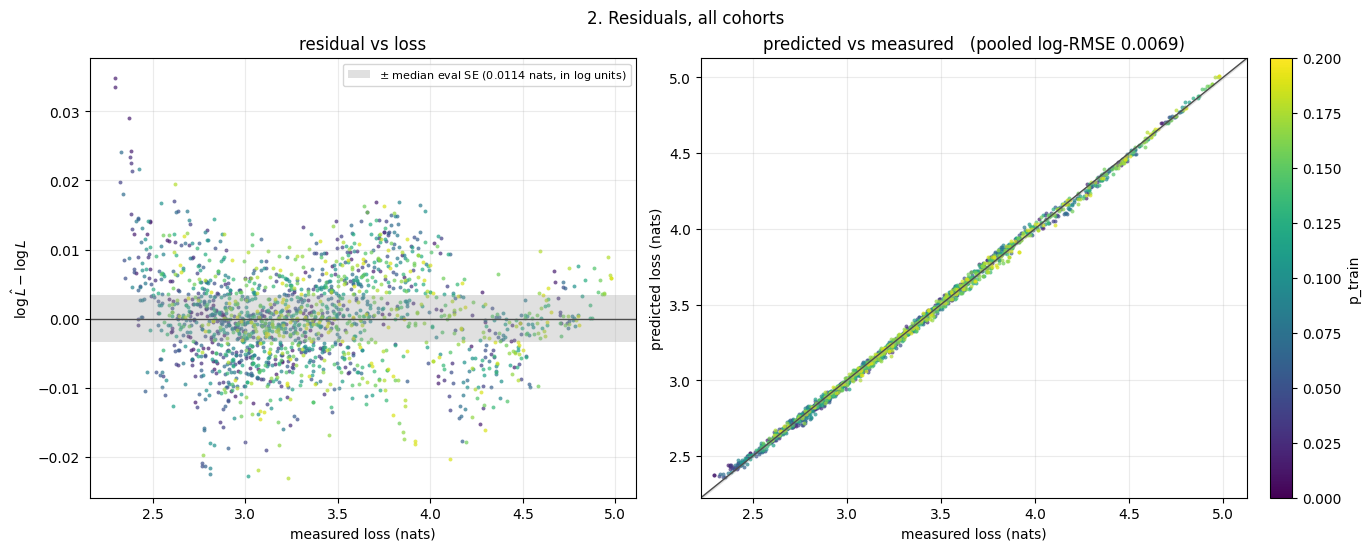

In [6]:
%matplotlib inline

def parts(p):
    """(N, D, L, predicted, log-residual, eval_se) for one cohort."""
    a = analyses[p]
    N, D, L = a["arr"]["N"], a["arr"]["D"], a["arr"]["L"]
    pred = a["fit"].predict(N, D)
    return N, D, L, pred, np.log(pred) - np.log(L), a["arr"]["eval_se"]

SE_MED = float(np.median(np.concatenate([analyses[p]["arr"]["eval_se"] for p in ps])))
allL = np.concatenate([analyses[p]["arr"]["L"] for p in ps])
lim = (allL.min() * 0.97, allL.max() * 1.03)

fig, ax = plt.subplots(1, 2, figsize=(13.6, 5.4), layout="constrained")
for p, c in zip(ps, colors):
    _, _, L, pred, r, _ = parts(p)
    ax[0].scatter(L, r, s=8, color=c, alpha=0.7, linewidths=0)
    ax[1].scatter(L, pred, s=8, color=c, alpha=0.7, linewidths=0)
ax[0].axhline(0, ls="-", lw=1, color="0.3")
ax[0].axhspan(-SE_MED / allL.mean(), SE_MED / allL.mean(), color="0.6", alpha=0.3, lw=0,
              label=f"$\\pm$ median eval SE ({SE_MED:.4f} nats, in log units)")
ax[0].set(xlabel="measured loss (nats)", ylabel=r"$\log \hat{L} - \log L$",
          title="residual vs loss")
ax[0].legend(fontsize=8)
ax[1].plot(lim, lim, "-", lw=1, color="0.3")
ax[1].fill_between(lim, np.array(lim) - SE_MED, np.array(lim) + SE_MED, color="0.6", alpha=0.3, lw=0)
rl = float(np.sqrt(np.mean(np.concatenate([parts(p)[4] for p in ps]) ** 2)))
ax[1].set(xlim=lim, ylim=lim, xlabel="measured loss (nats)", ylabel="predicted loss (nats)",
          title=f"predicted vs measured   (pooled log-RMSE {rl:.4f})")
for a_ in ax:
    a_.grid(alpha=0.25)
sm(ax)
fig.suptitle("2. Residuals, all cohorts")
plt.show()

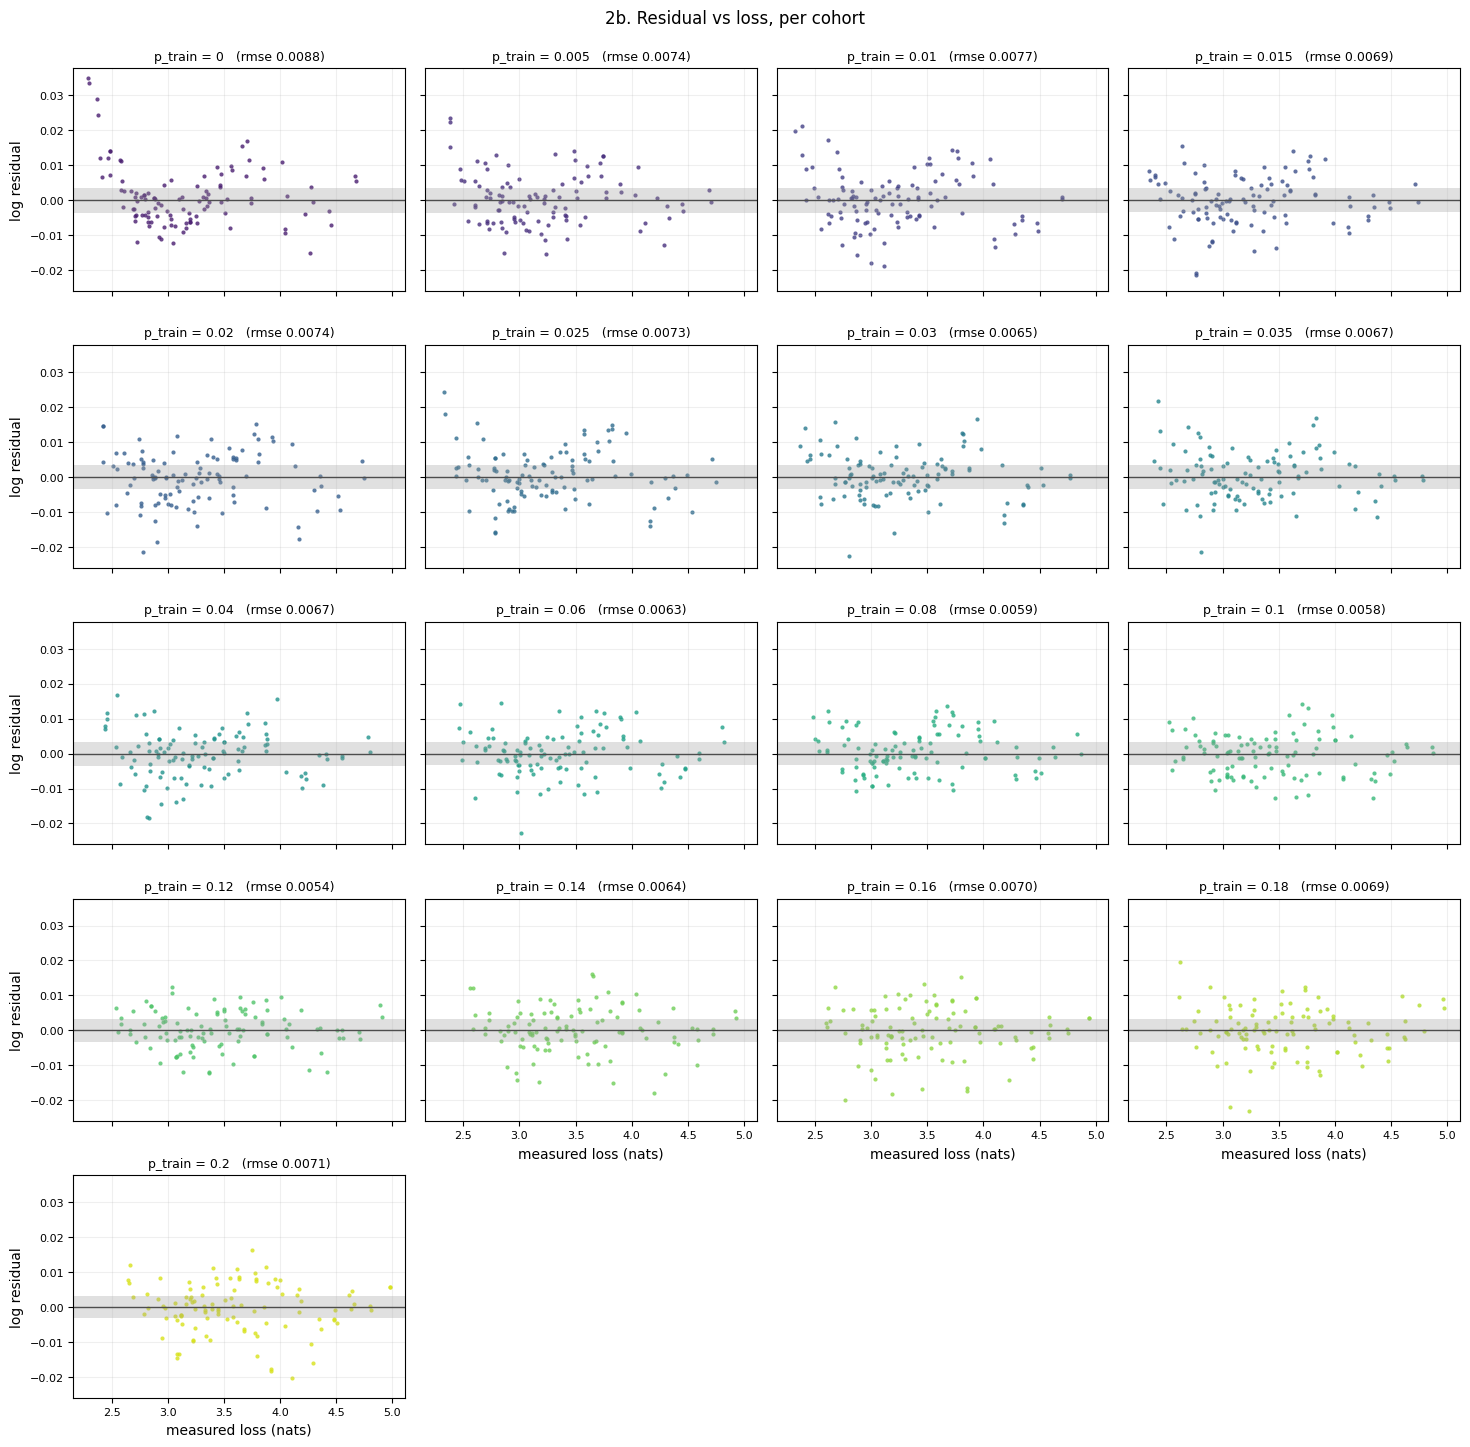

In [7]:
# Per-cohort, so a single bad cohort cannot hide in the pooled cloud.
ncols = 4
nrows = int(np.ceil(len(ps) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(3.7 * ncols, 2.9 * nrows), sharex=True, sharey=True)
for axi, (p, c) in zip(axes.flat, zip(ps, colors)):
    _, _, L, pred, r, _ = parts(p)
    axi.scatter(L, r, s=9, color=c, alpha=0.8, linewidths=0)
    axi.axhline(0, lw=1, color="0.3")
    axi.axhspan(-SE_MED / L.mean(), SE_MED / L.mean(), color="0.6", alpha=0.3, lw=0)
    axi.set_title(f"p_train = {p:g}   (rmse {np.sqrt(np.mean(r ** 2)):.4f})", fontsize=9)
    axi.grid(alpha=0.2)
    axi.tick_params(labelsize=8)
for axi in axes.flat[len(ps):]:
    axi.axis("off")
for col in range(ncols):                      # x labels on the last VISIBLE panel of each column
    rows = [r_ for r_ in range(nrows) if r_ * ncols + col < len(ps)]
    if rows:
        axes[rows[-1], col].set_xlabel("measured loss (nats)")
        axes[rows[-1], col].tick_params(labelbottom=True)
for axi in axes[:, 0]:
    axi.set_ylabel("log residual")
fig.suptitle("2b. Residual vs loss, per cohort", y=0.995)
fig.tight_layout()
plt.show()

## 3. Pairwise bootstrap results

A point cloud for each possible pair of fit parameters, to see what pairwise corrections exist between variables

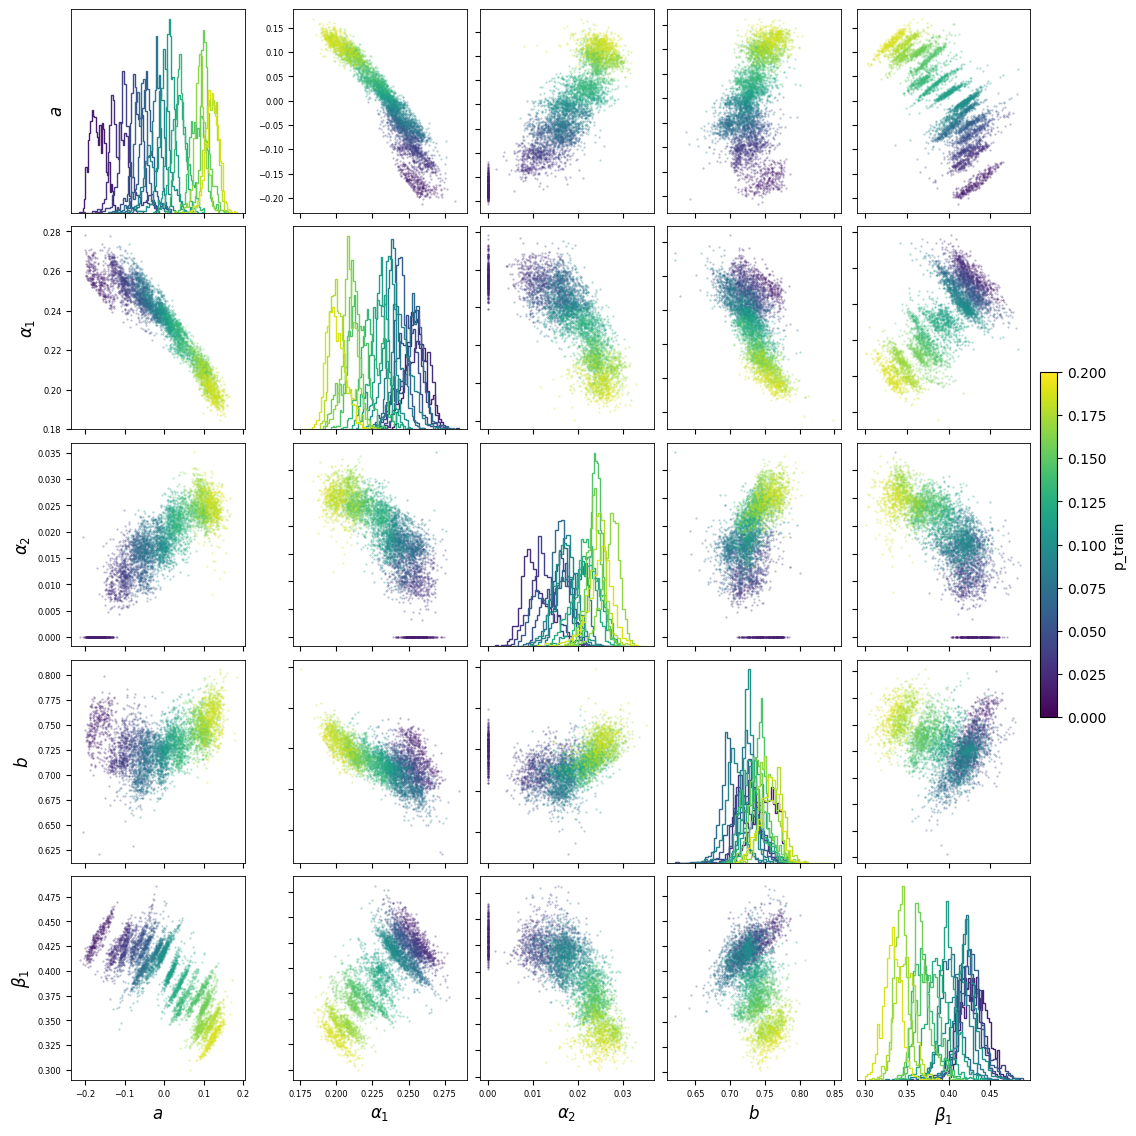

17 cohorts overlaid; off-diagonal = joint draws, diagonal = marginal.  Dropped (pinned by the fit, no spread): E, beta2

pairwise correlation of the bootstrap draws, per cohort

  p_train      a-alpha1      a-alpha2           a-b       a-beta1 alpha1-alpha2      alpha1-b  alpha1-beta1      alpha2-b  alpha2-beta1       b-beta1
-----------------------------------------------------------------------------------------------------------------------------------------------------
        0         -0.72           nan          0.48          0.92           nan         -0.71         -0.84           nan           nan          0.78
    0.005         -0.73          0.12          0.27          0.91         -0.24         -0.74         -0.90          0.42          0.15          0.61
     0.01         -0.82          0.05          0.35          0.94         -0.17         -0.55         -0.87          0.10         -0.00          0.62
    0.015         -0.72          0.04          0.26          0.89       

/home/trevor/scienv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3065: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/home/trevor/scienv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3066: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


In [8]:
# ---- the corner plot: every pair of fitted parameters, from the bootstrap draws ----------------
SHOW_COHORTS = ps                     # <-- SET: which cohorts to overlay (default: all)
DRAWS = 300                           # resample draws plotted per cohort per panel, for legibility
BINS = 30

CC = dict(zip(ps, colors))


def corner(pset, draws=DRAWS, bins=BINS):
    """Full pairwise grid over the cohorts in `pset`: scatter off the diagonal, marginals on it.

    BOTH triangles are drawn and carry the same pairs mirrored -- panel (i, j) always plots
    x = keys[j], y = keys[i]. The redundancy is the point: every ROW then shares one y variable and
    every COLUMN one x, so a single parameter's whole story reads off one line of the grid instead of
    turning a corner halfway along it.

    Coordinates with no spread anywhere in `pset` are dropped and returned: those are the ones the
    fit PINNED, and a constant has neither a distribution nor a correlation."""
    keys = [k for k in est.PARAM_NAMES
            if any(np.ptp(analyses[q]["boot"].samples[k]) > 0 for q in pset)]
    dropped = [k for k in est.PARAM_NAMES if k not in keys]
    n = len(keys)
    rng = np.random.default_rng(0)
    fig, axes = plt.subplots(n, n, figsize=(2.25 * n, 2.25 * n), sharex="col", layout="constrained")
    axes = np.atleast_2d(axes)

    for i in range(n):
        for j in range(n):
            ax = axes[i, j]
            if i == j:                                  # --- marginal ---
                for q in pset:
                    v = analyses[q]["boot"].samples[keys[i]]
                    if np.ptp(v) > 0:
                        ax.hist(v, bins=bins, histtype="step", color=CC[q], lw=1.0, density=True)
                ax.set_yticks([])                       # a density scale carries no information here
            else:                                       # --- joint draws: x = keys[j], y = keys[i] ---
                for q in pset:
                    smp = analyses[q]["boot"].samples
                    m = len(smp[keys[i]])
                    sel = rng.choice(m, size=min(draws, m), replace=False)
                    ax.scatter(smp[keys[j]][sel], smp[keys[i]][sel], s=2.5, color=CC[q],
                               alpha=0.35, linewidths=0)
            ax.tick_params(labelsize=6)
            for sp in ax.spines.values():
                sp.set_linewidth(0.6)

    # Names on the outer boundary, tick numbers only where they are unambiguous: a row's y scale is
    # read from its left-most SCATTER, which is column 0 -- except in row 0, where (0, 0) is a
    # density, so column 1 carries it instead.
    for j in range(n):
        axes[n - 1, j].set_xlabel(_PTITLE.get(keys[j], keys[j]), fontsize=12)
    for i in range(n):
        # Every row gets its name on the left, row 0 included: the row IS that variable, even though
        # its own (0, 0) panel is a density. Only the tick NUMBERS move to column 1 there.
        axes[i, 0].set_ylabel(_PTITLE.get(keys[i], keys[i]), fontsize=12)
        ycol = 0 if i != 0 else 1
        for j in range(n):
            if j != ycol or i == j:
                axes[i, j].tick_params(labelleft=False)

    cb = fig.colorbar(plt.cm.ScalarMappable(cmap=CMAP, norm=NORM), ax=axes.ravel().tolist(),
                      fraction=0.018, pad=0.01)
    cb.set_label("p_train", fontsize=10)
    return fig, keys, dropped


fig, KEYS, DROPPED = corner(SHOW_COHORTS)
plt.show()
print(f"{len(SHOW_COHORTS)} cohorts overlaid; off-diagonal = joint draws, diagonal = marginal."
      + (f"  Dropped (pinned by the fit, no spread): {', '.join(DROPPED)}" if DROPPED else ""))

# The correlations as a table, so a trend in p is readable rather than eyeballed off the clouds.
print("\npairwise correlation of the bootstrap draws, per cohort\n")
pairs = [(KEYS[i], KEYS[j]) for i in range(len(KEYS)) for j in range(i + 1, len(KEYS))]
print(f"{'p_train':>9}" + "".join(f"{f'{x}-{y}':>14}" for x, y in pairs))
print("-" * (9 + 14 * len(pairs)))
for q in ps:
    s = analyses[q]["boot"].samples
    print(f"{q:>9g}" + "".join(f"{float(np.corrcoef(s[x], s[y])[0, 1]):>14.2f}" for x, y in pairs))

## 5. Capacity retained, $N_\mathrm{eff}/N$

Main text Fig. 1

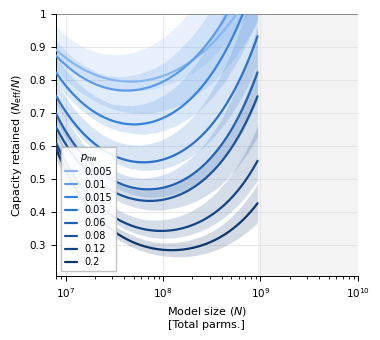

In [10]:
%matplotlib inline

CAP_SHOW = [0.005, 0.01, 0.015, 0.03, 0.06, 0.08, 0.12, 0.2]
CAP_BAND = (25, 75)                   # percentile band from the PAIRED bootstrap; None to skip
NGRID = 200

CAP_XMAX = 1.0e10
CAP_YTOP = 1.0
CAP_SHADE = 0.09

BASE = ps[0]
f0 = analyses[BASE]["fit"]


def log_cap_ratio(a_p, al1_p, al2_p, E_p, a0, al10, al20, E0, n):
    """log(N_eff / N) -- the exact root of the quadratic in m = log(N_eff/N0). Arrays broadcast."""
    T = E_p + np.exp(a_p - al1_p * n - al2_p * n ** 2)          # faulted saturated loss
    with np.errstate(invalid="ignore", divide="ignore"):
        c = np.log(T - E0) - a0
        disc = al10 ** 2 - 4.0 * al20 * c
        m = -2.0 * c / (al10 + np.sqrt(disc))
    return np.where((T > E0) & (disc >= 0), m - n, np.nan)


Nlo = min(analyses[q]["arr"]["N"].min() for q in [BASE] + CAP_SHOW)
Nhi = max(analyses[q]["arr"]["N"].max() for q in [BASE] + CAP_SHOW)
Ng = np.geomspace(Nlo, Nhi, NGRID)
n = np.log(Ng / f0.N0)

from matplotlib.colors import LinearSegmentedColormap
from matplotlib.ticker import FuncFormatter, NullFormatter

_RAMP_STEPS = ["#86b6ef", "#3987e5", "#256abf", "#184f95", "#0d366b"]
_ramp = LinearSegmentedColormap.from_list("seq_blue_ordinal", _RAMP_STEPS)
RAMP = ([_ramp(0.75)] if len(CAP_SHOW) == 1
        else [_ramp(x) for x in np.linspace(0.0, 1.0, len(CAP_SHOW))])

fig, ax = plt.subplots(figsize=(3.9, 3.5))
rows = []
for q, col in zip(CAP_SHOW, RAMP):
    fq = analyses[q]["fit"]
    r = np.exp(log_cap_ratio(fq.a, fq.alpha1, fq.alpha2, fq.E,
                             f0.a, f0.alpha1, f0.alpha2, f0.E, n))
    if CAP_BAND is not None:                      # PAIRED bootstrap: draw i vs draw i
        s0, sq = analyses[BASE]["boot"].samples, analyses[q]["boot"].samples
        k = min(len(s0["a"]), len(sq["a"]))
        colf = lambda s, key: s[key][:k, None]
        B = np.exp(log_cap_ratio(colf(sq, "a"), colf(sq, "alpha1"), colf(sq, "alpha2"),
                                 colf(sq, "E"), colf(s0, "a"), colf(s0, "alpha1"),
                                 colf(s0, "alpha2"), colf(s0, "E"), n[None, :]))
        lo, hi = np.nanpercentile(B, CAP_BAND, axis=0)
        ax.fill_between(Ng, lo, hi, color=col, alpha=0.18, lw=0, zorder=1)
    ax.plot(Ng, r, color=col, lw=1.6, solid_capstyle="round", zorder=3, label=f"{q:g}")
    rows.append((q, r))

if CAP_XMAX is not None:                                 # the empty block, for a hand-drawn cartoon
    ax.axvspan(Ng[-1], CAP_XMAX, color="0.5", alpha=CAP_SHADE, lw=0, zorder=0)
ax.axhline(1.0, color="0.55", lw=0.7, zorder=2)          # parity with a fault-free model
ax.set_xscale("log")


ax.yaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{v:g}"))
ax.yaxis.set_minor_formatter(NullFormatter())
ax.set_xlim(Ng[0], Ng[-1] if CAP_XMAX is None else CAP_XMAX)
if CAP_YTOP is not None:
    ax.set_ylim(top=CAP_YTOP)
ax.set_xlabel(r"Model size ($N$)" + "\n[Total parms.]", fontsize=8)
ax.set_ylabel(r"Capacity retained ($N_\mathrm{eff}/N$)", fontsize=8)
ax.tick_params(labelsize=7.5, width=0.7)

ax.grid(True, which="major", axis="x", color="0.88", lw=0.5, ls="-", zorder=0)
ax.grid(True, which="major", axis="y", color="0.88", lw=0.5, ls="-", zorder=0)
ax.grid(True, which="minor", axis="y", color="0.94", lw=0.4, ls="-", zorder=0)
ax.set_axisbelow(True)                                   # grid behind the bands, not through them
for side in ("top", "right"):
    ax.spines[side].set_visible(False)
for side in ("left", "bottom"):
    ax.spines[side].set_linewidth(0.7)
ax.legend(fontsize=7, loc="lower left", title=r"$p_\mathrm{hw}$", title_fontsize=7,
          handlelength=1.2, labelspacing=0.3, borderpad=0.45, frameon=True, framealpha=0.92,
          edgecolor="0.75", fancybox=False)
fig.tight_layout()
plt.show()


## 6. the exponents, and what a falling data exponent costs

Main text Fig. 3

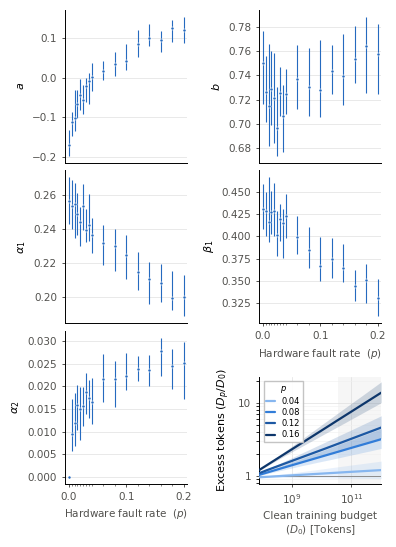

In [13]:

SAVE_PATH = None
COST_PS = [0.04, 0.08, 0.12, 0.16]
D_HI = 1e12

from matplotlib.colors import LinearSegmentedColormap
from matplotlib.ticker import FixedLocator, FuncFormatter, MaxNLocator, NullFormatter

MARK, INK_SOFT = "#256abf", "#52514e"
_RAMP_STEPS = ["#86b6ef", "#3987e5", "#256abf", "#184f95", "#0d366b"]
_ramp = LinearSegmentedColormap.from_list("seq_blue_ordinal", _RAMP_STEPS)

xs = np.asarray(ps, float)          # TRUE p: the grid is uneven and a categorical axis would lie
BASE = ps[0]
f0 = analyses[BASE]["fit"]


def _pt_ci(q, key):
    """(point fit, 2.5 pct, 97.5 pct) for one parameter at cohort q."""
    lo, hi = np.percentile(analyses[q]["boot"].samples[key], [2.5, 97.5])
    return float(getattr(analyses[q]["fit"], key)), float(lo), float(hi)


def token_tax(q, Dg):
    """(n_boot, len(Dg)) multiplier D_p/D_0 -- see the markdown. Paired by resample index."""
    su, sf = analyses[BASE]["boot"].samples, analyses[q]["boot"].samples
    K = min(len(su["b"]), len(sf["b"]))
    v0 = np.log(Dg / f0.D0)[None, :]
    bu, be_u = su["b"][:K, None], su["beta1"][:K, None]
    bf, be_f = sf["b"][:K, None], sf["beta1"][:K, None]
    return np.exp((bf - bu) / be_f + v0 * (be_u / be_f - 1.0))


def _style(ax):
    ax.tick_params(labelsize=7.5, width=0.7, length=2.5, colors=INK_SOFT)
    ax.set_axisbelow(True)
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)
    for side in ("left", "bottom"):
        ax.spines[side].set_linewidth(0.7)


PANELS = [("a", r"$a$"), ("b", r"$b$"),
          ("alpha1", r"$\alpha_1$"), ("beta1", r"$\beta_1$"),
          ("alpha2", r"$\alpha_2$")]

H_TIGHT, H_LOOSE = 0.014, 0.098
LFT, RGT, TOP, BOT, W_GAP = 0.150, 0.960, 0.980, 0.105, 0.185
W = (RGT - LFT - W_GAP) / 2.0
PITCH = (TOP - BOT) / 3.0                # the shared row pitch
PANEL_H = PITCH - H_TIGHT

fig = plt.figure(figsize=(3.9, 5.5))
_XR = LFT + W + W_GAP

def _panel(x, row, shrink=0.0):
    """A panel on the shared 3-row grid, trimmed from the TOP by ``shrink`` so the row boundary --
    and therefore the seam -- does not move."""
    return fig.add_axes([x, TOP - row * PITCH - PANEL_H, W, PANEL_H - shrink])

axL = [_panel(LFT, j) for j in range(3)]                     # a, alpha1, alpha2
axR = [_panel(_XR, j) for j in range(2)]                     # b, beta1

axC = _panel(_XR, 2, shrink=H_LOOSE - H_TIGHT)
PARAM_AXES = [axL[0], axR[0], axL[1], axR[1], axL[2]]

for ax, (key, ylab) in zip(PARAM_AXES, PANELS):
    v, lo, hi = np.array([_pt_ci(q, key) for q in ps]).T
    ax.vlines(xs, lo, hi, color=MARK, lw=0.8, zorder=2)
    ax.plot(xs, v, "o", ms=2.2, color=MARK, mec="white", mew=0.4, zorder=3)
    ax.set_ylabel(ylab, fontsize=8)
    ax.grid(True, which="major", axis="y", color="0.88", lw=0.5, zorder=0)
    _style(ax)

_maj = MaxNLocator(nbins=3, steps=[1, 2, 5]).tick_values(xs.min(), xs.max())
_maj = _maj[(_maj >= xs.min()) & (_maj <= xs.max())]
for ax in PARAM_AXES:
    ax.set_xlim(xs.min() - 0.03 * np.ptp(xs), xs.max() + 0.03 * np.ptp(xs))
    ax.xaxis.set_major_locator(FixedLocator(_maj))
    ax.xaxis.set_minor_locator(FixedLocator(xs))
    ax.tick_params(axis="x", which="minor", length=1.5, width=0.5, colors=INK_SOFT)
# Only the LAST panel of each group carries the shared p axis: inside a group the panels are close
# enough that a repeated axis would read as a divider and undo the grouping.
for ax in (axL[0], axL[1], axR[0]):
    # bottom=False, not just labelbottom: with zero gap, outward tick marks would otherwise be drawn
    # across the top of the panel below.
    ax.tick_params(axis="x", which="both", bottom=False, labelbottom=False)
for ax in (axL[2], axR[1]):
    ax.set_xlabel(r"Hardware fault rate  ($p$)", fontsize=7.5, color=INK_SOFT)

# ---- the cost panel: section 7's lower-plot treatment -----------------------------------------
D_data = max(analyses[q]["arr"]["D"].max() for q in ps)
Dg = np.geomspace(min(analyses[q]["arr"]["D"].min() for q in ps), D_HI, 200)
RAMP = ([_ramp(0.75)] if len(COST_PS) == 1
        else [_ramp(x) for x in np.linspace(0.0, 1.0, len(COST_PS))])
for q, col in zip(COST_PS, RAMP):
    T = token_tax(q, Dg)
    lo, hi = np.nanpercentile(T, [25, 75], axis=0)
    med = np.nanmedian(T, axis=0)
    axC.fill_between(Dg, lo, hi, color=col, alpha=0.18, lw=0, zorder=1)
    axC.plot(Dg, med, color=col, lw=1.6, solid_capstyle="round", zorder=3, label=f"{q:g}")
axC.axhline(1.0, color="0.55", lw=0.7, zorder=2)                     # parity: no extra tokens
axC.axvspan(D_data, Dg[-1], color="0.5", alpha=0.07, lw=0, zorder=0)  # beyond the measured design
axC.set_xscale("log"); axC.set_yscale("log")
axC.yaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{v:g}"))
axC.yaxis.set_minor_formatter(NullFormatter())
axC.set_xlim(Dg[0], Dg[-1])
axC.set_xlabel(r"Clean training budget" "\n" r"($D_0$) [Tokens]", fontsize=7.5,
               color=INK_SOFT)
axC.set_ylabel(r"Excess tokens ($D_p/D_0$)", fontsize=8)
axC.grid(True, which="major", axis="x", color="0.88", lw=0.5, zorder=0)
axC.grid(True, which="major", axis="y", color="0.88", lw=0.5, zorder=0)
axC.grid(True, which="minor", axis="y", color="0.94", lw=0.4, zorder=0)
_style(axC)
axC.legend(fontsize=6, loc="upper left", title=r"$p$", title_fontsize=6, handlelength=1.0,
           labelspacing=0.25, borderpad=0.35, frameon=True, framealpha=0.92, edgecolor="0.75",
           fancybox=False)

fig.align_ylabels(axL)                 # align within each column so the groups read as solid blocks
fig.align_ylabels(axR + [axC])
if SAVE_PATH:
    fig.savefig(SAVE_PATH, dpi=600)        # no bbox_inches="tight": keep the declared 3.4 in width
    print(f"wrote {SAVE_PATH}")
plt.show()

